dyngen(spatial)绘制指标

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = '../clusters/dyngen.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [4]:
save_dir = '../figures/dyngen/spatial'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [5]:
data = 'dyngen/spatial'

绘制CBDir

In [24]:
metric_name = 'cbdir'
basis = 'coord'
models = ['topovelo_KNN', 'topovelo_Delaunay', 'stt']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = metric[edge]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt(vj)'] = stt_metric[edge]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if edge in ltv_metric.keys():
                result[f'{key}(lt)'] = ltv_metric[edge]
    results[edge] = result

In [25]:
results_2d = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = metric[edge]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt(vj)'] = stt_metric[edge]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if edge in ltv_metric.keys():
                result[f'{key}(lt)'] = ltv_metric[edge]
    results_2d[edge] = result

In [26]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
edge_color_map = dict(zip(results.keys(), colors))

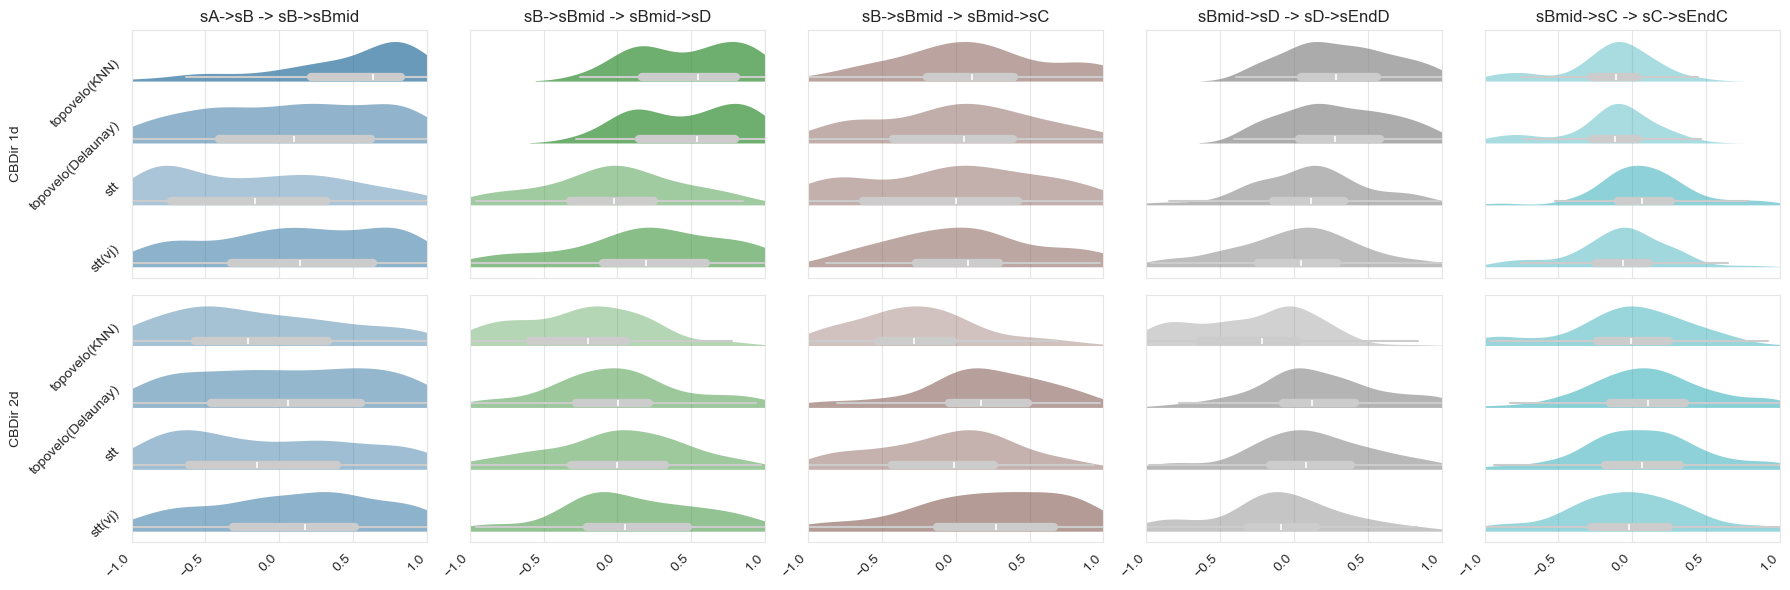

In [27]:
fig, axs = plt.subplots(nrows=2, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    ax = axs[0, i]
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[edge], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='count', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=ax, 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    ax.set_title(edge)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('')
    ax.set_ylabel('CBDir 1d')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
for i, (edge, result) in enumerate(results_2d.items()):
    ax = axs[1, i]
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[edge], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='count', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=ax, 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    # ax.set_title(edge)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('')
    ax.set_ylabel('CBDir 2d')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}_{basis}.svg')
plt.show()

绘制ICCoh

In [10]:
metric_name = 'inner_cluster_coh'
models = ['topovelo_KNN', 'topovelo_Delaunay', 'stt']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        result[key] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result[f'{key}(lt)'] = ltv_metric[cluster]
    results[cluster] = result

In [11]:
results_2d = {}
for cluster in clusters:
    result = {}
    for model in models:
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
        result[key] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model_name == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}_2d/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result[f'{key}(lt)'] = ltv_metric[cluster]
    results_2d[cluster] = result

In [12]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
cluster_color_map = dict(zip(results.keys(), colors))

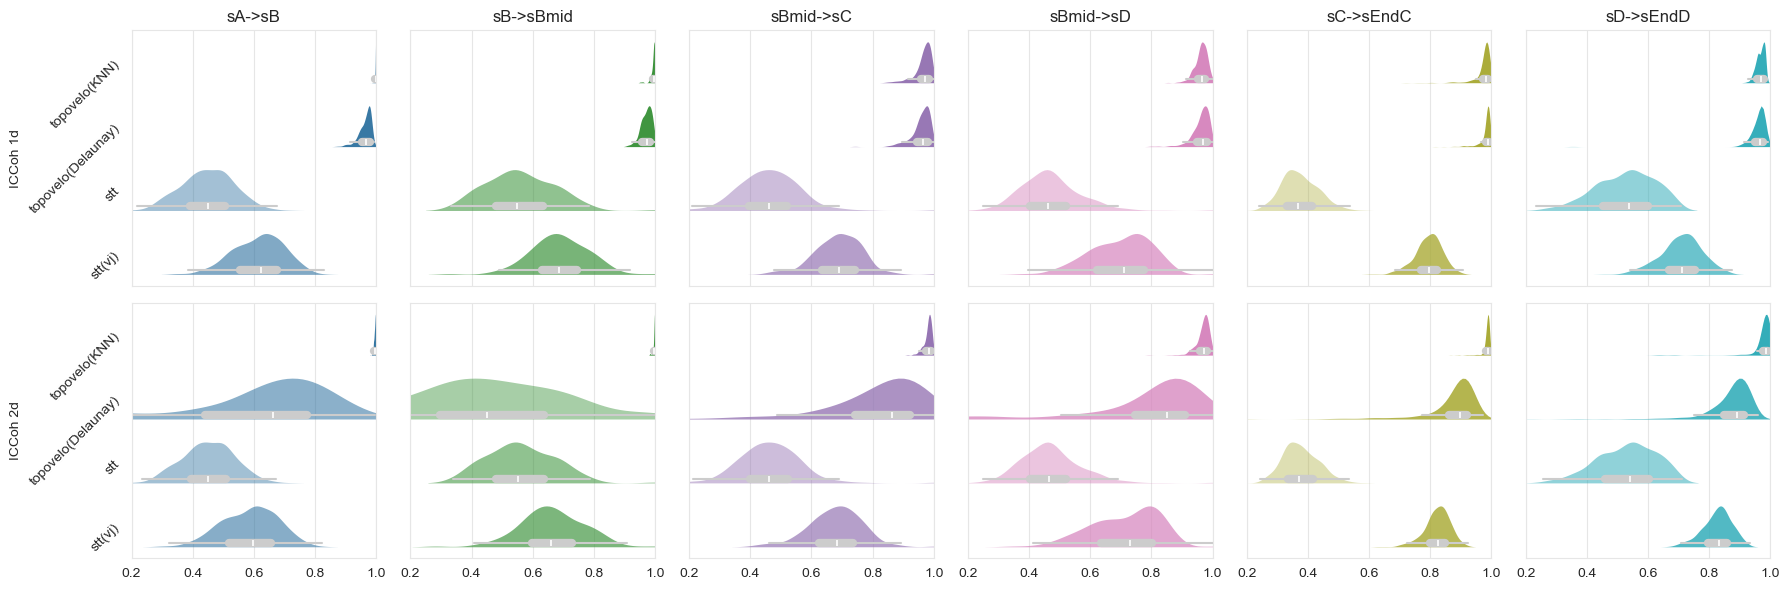

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    ax = axs[0, i]
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = ax, 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    ax.set_title(cluster)
    ax.set_xlim(0.2, 1)
    ax.set_xlabel('')
    ax.set_ylabel('ICCoh 1d')
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
for i, (cluster, result) in enumerate(results_2d.items()):
    ax = axs[1, i]
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = ax, 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    # ax.set_title(cluster)
    ax.set_xlim(0.2, 1)
    ax.set_xlabel('')
    ax.set_ylabel('ICCoh 2d')
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}_{basis}.svg')
plt.show()

绘制k-CBDir

In [14]:
import re
import ast

In [28]:
k = 5
basis = 'coord'
metric_name = 'gen_cbdir_edge'
models = ['topovelo_KNN', 'topovelo_Delaunay', 'stt']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'\s+', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model_name == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[f'{key}(lt)'] = cbdir
    results[edge] = result

In [29]:
results_2d = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}_2d/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}_2d/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'\s+', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model_name == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result[f'{key}(lt)'] = cbdir
    results_2d[edge] = result

In [31]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovi': plt.cm.Set2(2 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'stt(vj)': plt.cm.Set2(4 / 8),
    'topovelo(KNN)': plt.cm.Set2(6 / 8),
    'topovelo(Delaunay)': plt.cm.Set3(1 / 12),
    'velovae(prior)': plt.cm.Set3(7 / 12),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'latentvelo(prior)': plt.cm.Set3(10 / 12),
    'latentvelo': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)': plt.cm.tab20c(15 / 20),
    'latentvelo(prior)(lt)': plt.cm.Set3(10 / 12),
    'latentvelo(lt)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)(lt)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(lt)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)(lt)': plt.cm.tab20c(15 / 20),
    'velovgi': plt.cm.tab20c(0 / 20),
    'velovgi(batch)': plt.cm.tab20c(3 / 20),
}
line_styles = {
    'scvelo': (1, 0),  # '-' 实线
    'unitvelo': (1, 0),  # '-' 实线
    'velovi': (1, 0),  # '-' 实线
    'velovae': (1, 0),  # '-' 实线
    'stt': (1, 0),  # '-' 实线
    'stt(vj)': (4, 2),  # '--' 虚线
    'topovelo(KNN)': (1, 0),  # '-' 实线
    'topovelo(Delaunay)': (1, 0),  # '-' 实线
    'velovae(prior)': (1, 0),  # '-' 实线
    'deepvelo(cui)': (1, 0),  # '-' 实线
    'latentvelo(prior)': (1, 0),  # '-' 实线
    'latentvelo': (1, 0),  # '-' 实线
    'latentvelo(batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)': (1, 0),  # '-' 实线
    'latentvelo(annot)(batch)': (1, 0),  # '-' 实线
    'latentvelo(prior)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(lt)': (4, 2),  # '--' 虚线
    'latentvelo(batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(batch)(lt)': (4, 2),  # '--' 虚线
    'velovgi': (1, 0),  # '-' 实线
    'velovgi(batch)': (1, 0),  # '-' 实线
}

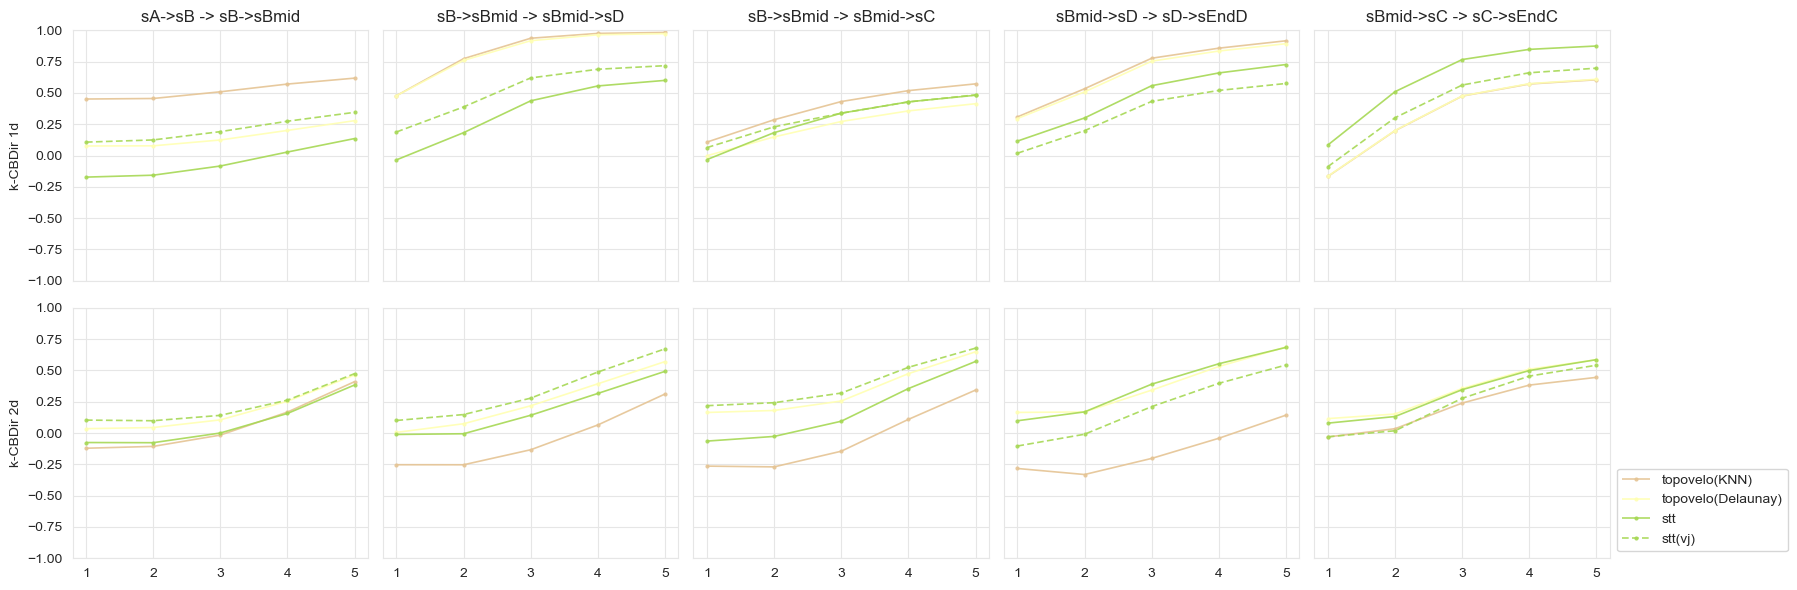

In [32]:
fig, axs = plt.subplots(nrows=2, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    ax = axs[0, i]
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors,
        style='model',
        dashes=line_styles, 
        ax=ax, 
        linewidth=1.2,
        alpha=0.9,
        markersize=3,
        marker='o',
        markeredgewidth=0,
    )
    ax.set_title(edge)
    ax.set_xlabel('')
    ax.set_ylabel('k-CBDir 1d')
    ax.set_ylim(-1, 1)
    ax.get_legend().remove()
for i, (edge, result) in enumerate(results_2d.items()):
    ax = axs[1, i]
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors,
        style='model',
        dashes=line_styles, 
        ax=ax, 
        linewidth=1.2,
        alpha=0.9,
        markersize=3,
        marker='o',
        markeredgewidth=0,
    )
    # ax.set_title(edge)
    ax.set_xlabel('')
    ax.set_ylabel('k-CBDir 2d')
    ax.set_ylim(-1, 1)
    ax.get_legend().remove()

handles, labels = axs[0, 0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}_{basis}.svg', bbox_inches='tight')
plt.show()

Time Corr & Velocity Acc

In [19]:
metrics = ['time_corr_spearman', 'velocity_acc']
models = ['topovelo_KNN', 'topovelo_Delaunay', 'stt']
results = {}
for metric_name in metrics:
    result = {}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if metric_name == 'time_corr_spearman':
            if model_name == 'stt':
                continue
            if model_name not in ['velovi', 'velovgi']:
                idx_name = f'{metric_name}_pred_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'])
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = t_corr
            if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
                idx_name = f'{metric_name}_fit_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'])
                key = f'{model}(avg)' if model == 'scvelo' else model
                result[key] = t_corr
        if metric_name == 'velocity_acc':
            idx_name = f'{metric_name}_{model_name}_velocity'
            v_acc = float(metric.loc[metric.index == idx_name, '0'])
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = v_acc
            if model_name == 'latentvelo':
                ltv_idx_name = f'{metric_name}_latent_velocity'
                v_acc = float(metric.loc[metric.index == ltv_idx_name, '0'])
                result[f'{key}(lt)'] = v_acc
    results[metric_name] = result

/tmp/ipykernel_2028778/343496417.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_corr = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/343496417.py:24: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_corr = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/343496417.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_acc = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/343496417.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_acc = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/3434964

In [20]:
results_2d = {}
for metric_name in metrics:
    result = {}
    for model in models: 
        if model == 'scvelo':
            model_name = 'scvelo_dynamical'
        elif model.startswith('latentvelo'):
            model_name = 'latentvelo'
        elif model.startswith('topovelo'):
            model_name = 'topovelo'
        else:
            model_name = model
        metric_file = f'{base_dir}/{data}_2d/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}_2d/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if metric_name == 'time_corr_spearman':
            if model_name == 'stt':
                continue
            if model_name not in ['velovi', 'velovgi']:
                idx_name = f'{metric_name}_pred_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'])
                key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
                result[key] = t_corr
            if model_name in ['scvelo_dynamical', 'velovi', 'velovgi']:
                idx_name = f'{metric_name}_fit_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'])
                key = f'{model}(avg)' if model == 'scvelo' else model
                result[key] = t_corr
        if metric_name == 'velocity_acc':
            idx_name = f'{metric_name}_{model_name}_velocity'
            v_acc = float(metric.loc[metric.index == idx_name, '0'])
            key = f'{model.split("_")[0]}({model.split("_")[-1]})' if '_' in model else model
            result[key] = v_acc
            if model_name == 'latentvelo':
                ltv_idx_name = f'{metric_name}_latent_velocity'
                v_acc = float(metric.loc[metric.index == ltv_idx_name, '0'])
                result[f'{key}(lt)'] = v_acc
    results_2d[metric_name] = result

/tmp/ipykernel_2028778/610909846.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_corr = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/610909846.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  t_corr = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/610909846.py:32: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_acc = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/610909846.py:32: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  v_acc = float(metric.loc[metric.index == idx_name, '0'])
/tmp/ipykernel_2028778/6109098

In [21]:
color_maps = [plt.cm.Blues, plt.cm.Greens]

In [22]:
models_total = ['topovelo(KNN)', 'topovelo(Delaunay)', 'stt']

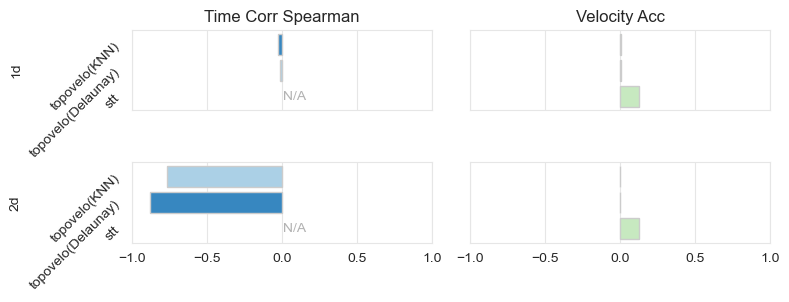

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=len(results), sharex=True, sharey=True, figsize=(8, 3))
for i, (metric_name, result) in enumerate(results.items()):
    ax = axs[0, i]
    result_sorted = {model: result.get(model, float('nan')) for model in models_total}
    df = pd.DataFrame(list(result_sorted.items()), columns=['model', metric_name])
    color_map = color_maps[i]
    sns.barplot(data=df, x=metric_name, y='model', ax=ax, orient='h')
    df['rank'] = df[metric_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric_name], df['rank'])):
        if pd.isna(value):
            ax.text(x=0.01, y=j, s='N/A', ha='left', va='center', fontsize=10, color='.7')
        else:
            ax.barh(model, value, color=color_map(rank / (len(result) + 1)), edgecolor='.8', linewidth=1)
    ax.set_title(metric_name.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('1d')
    ax.set_xlim(-1, 1)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
for i, (metric_name, result) in enumerate(results_2d.items()):
    ax = axs[1, i]
    result_sorted = {model: result.get(model, float('nan')) for model in models_total}
    df = pd.DataFrame(list(result_sorted.items()), columns=['model', metric_name])
    color_map = color_maps[i]
    sns.barplot(data=df, x=metric_name, y='model', ax=ax, orient='h')
    df['rank'] = df[metric_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric_name], df['rank'])):
        if pd.isna(value):
            ax.text(x=0.01, y=j, s='N/A', ha='left', va='center', fontsize=10, color='.7')
        else:
            ax.barh(model, value, color=color_map(rank / (len(result) + 1)), edgecolor='.8', linewidth=1)
    # ax.set_title(metric_name.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('2d')
    ax.set_xlim(-1, 1)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(results.keys())}_{basis}.svg', bbox_inches='tight')
plt.show()